# Custom User Data: Loading, Formatting, Training, and Inference

This notebook shows how to bring **your own** spatiotemporal graph measurements into
KoopmanGraph. Unlike the benchmark tutorials (`01`–`04`), we start from raw arrays and
CSV files, then format them for :meth:`~koopman_graph.model.GraphKoopmanModel.fit`
and :meth:`~koopman_graph.model.GraphKoopmanModel.predict`.

The central container is :class:`~koopman_graph.data.GraphSnapshotSequence`: a
time-ordered list of PyG ``Data`` snapshots that share one fixed topology.


## Data contract

KoopmanGraph expects:

| Object | Shape / type | Notes |
|--------|----------------|-------|
| Node features per snapshot | `(num_nodes, in_channels)` | One matrix per timestep |
| Full feature history | `(num_timesteps, num_nodes, in_channels)` | Common numpy/torch layout |
| ``edge_index`` | `(2, num_edges)`, ``dtype=int64`` | Shared by **all** snapshots |
| Training sequence | ≥ 2 snapshots | ``fit`` needs consecutive pairs |

Every snapshot must use the **same** ``edge_index``, node count, and feature dimension.
Node IDs are row indices `0 … num_nodes-1` in the feature matrices.


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os
import tempfile
from pathlib import Path

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel, GraphSnapshotSequence
from koopman_graph.training import constant_loss_weights


## 1. Stand-in "user" measurements

We simulate a small sensor network on a **path graph** (chain topology). Node features
**diffuse along edges** and decay slowly — dynamics that align with what a
topology-aware Koopman model is designed to learn. In practice your arrays might come
from HDF5, Parquet, a database export, or instrument logs.


In [2]:
NUM_NODES = 10
NUM_TIMESTEPS = 20 if os.environ.get("PYTEST_CURRENT_TEST") else 36
IN_CHANNELS = 2
SEED = 7

DECAY_RATE = 0.99
DIFFUSION_RATE = 0.05
NOISE_STD = 0.001

rng = np.random.default_rng(SEED)

# Bidirectional path-graph edges (undirected edges need both directions in PyG)
sources: list[int] = []
targets: list[int] = []
for node in range(NUM_NODES - 1):
    sources.extend([node, node + 1])
    targets.extend([node + 1, node])
edge_index_np = np.asarray([sources, targets], dtype=np.int64)

# Initial node features, then graph-coupled diffusion + decay
node_features_np = np.zeros((NUM_TIMESTEPS, NUM_NODES, IN_CHANNELS), dtype=np.float32)
state = np.zeros((NUM_NODES, IN_CHANNELS), dtype=np.float32)
state[:, 0] = np.linspace(0.8, 1.2, NUM_NODES)
state[:, 1] = np.linspace(1.1, 0.9, NUM_NODES)
node_features_np[0] = state

neighbors: dict[int, list[int]] = {i: [] for i in range(NUM_NODES)}
for src, dst in zip(edge_index_np[0], edge_index_np[1], strict=True):
    neighbors[int(src)].append(int(dst))

for t in range(1, NUM_TIMESTEPS):
    updated = DECAY_RATE * state
    for node in range(NUM_NODES):
        nbrs = neighbors[node]
        if nbrs:
            nbr_mean = state[nbrs].mean(axis=0)
            updated[node] += DIFFUSION_RATE * (nbr_mean - state[node])
    state = updated.astype(np.float32)
    state += rng.normal(0.0, NOISE_STD, size=state.shape).astype(np.float32)
    node_features_np[t] = state

print(f"features shape: {node_features_np.shape}")
print(f"edge_index shape: {edge_index_np.shape}")


features shape: (36, 10, 2)
edge_index shape: (2, 18)


## 2. Build a ``GraphSnapshotSequence`` from arrays

:meth:`~koopman_graph.data.GraphSnapshotSequence.from_arrays` is the fastest path
when you already have a numpy or torch tensor with shape
``(num_timesteps, num_nodes, in_channels)``.


In [3]:
data_sequence = GraphSnapshotSequence.from_arrays(node_features_np, edge_index_np)

print(data_sequence.num_timesteps, data_sequence.num_nodes, data_sequence.in_channels)
print(data_sequence.edge_index.dtype, data_sequence[0].x.dtype)
assert data_sequence[3].x.shape == (NUM_NODES, IN_CHANNELS)


36 10 2
torch.int64 torch.float32


## 3. Alternative: assemble from PyG ``Data`` snapshots

If each timestep is already a separate ``Data`` object (for example after per-file
loading), pass a list to :class:`~koopman_graph.data.GraphSnapshotSequence` directly.
``fit`` and ``predict`` also accept a plain ``list[Data]``; the wrapper validates
shared topology for you.


In [4]:
edge_index = torch.as_tensor(edge_index_np, dtype=torch.long)
snapshots = [
    Data(x=torch.as_tensor(node_features_np[t]), edge_index=edge_index)
    for t in range(NUM_TIMESTEPS)
]
from_list = GraphSnapshotSequence(snapshots)

assert from_list.num_timesteps == data_sequence.num_timesteps
assert torch.equal(from_list.edge_index, data_sequence.edge_index)


## 4. Load from CSV files

Many teams store graph structure and time series separately. A typical layout:

- ``edges.csv`` — columns ``source``, ``target`` (integer node indices)
- ``features.csv`` — long format: ``timestep``, ``node``, ``feature_0``, …

Below we write those files to a temporary directory, then reload them into a
``GraphSnapshotSequence``.


In [5]:
data_dir = Path(tempfile.mkdtemp(prefix="koopman_custom_"))

edges_df = pd.DataFrame({"source": sources, "target": targets})
edges_df.to_csv(data_dir / "edges.csv", index=False)

rows = []
for t in range(NUM_TIMESTEPS):
    for node in range(NUM_NODES):
        rows.append(
            {
                "timestep": t,
                "node": node,
                "feature_0": float(node_features_np[t, node, 0]),
                "feature_1": float(node_features_np[t, node, 1]),
            }
        )
features_df = pd.DataFrame(rows)
features_df.to_csv(data_dir / "features.csv", index=False)

print(f"Wrote CSV bundle to {data_dir}")


Wrote CSV bundle to /var/folders/_j/45bljkj97jd5f7y7xgm6bpyr0000gn/T/koopman_custom_jrkkzfqg


In [6]:
def load_graph_snapshot_sequence_from_csv(
    features_csv: Path,
    edges_csv: Path,
    *,
    feature_columns: list[str],
) -> GraphSnapshotSequence:
    """Load long-format node features and an edge list into a snapshot sequence."""
    features = pd.read_csv(features_csv)
    edges = pd.read_csv(edges_csv)

    timesteps = sorted(features["timestep"].unique())
    nodes = sorted(features["node"].unique())
    num_nodes = len(nodes)
    in_channels = len(feature_columns)

    array = np.zeros((len(timesteps), num_nodes, in_channels), dtype=np.float32)
    for t_idx, timestep in enumerate(timesteps):
        frame = features.loc[features["timestep"] == timestep].set_index("node")
        for node in nodes:
            array[t_idx, node] = frame.loc[node, feature_columns].to_numpy(dtype=np.float32)

    edge_index = np.asarray(
        [edges["source"].to_numpy(dtype=np.int64), edges["target"].to_numpy(dtype=np.int64)]
    )
    return GraphSnapshotSequence.from_arrays(array, edge_index)


loaded_sequence = load_graph_snapshot_sequence_from_csv(
    data_dir / "features.csv",
    data_dir / "edges.csv",
    feature_columns=["feature_0", "feature_1"],
)
print(
    f"Loaded {loaded_sequence.num_timesteps} snapshots, "
    f"{loaded_sequence.num_nodes} nodes, {loaded_sequence.in_channels} features"
)


Loaded 36 snapshots, 10 nodes, 2 features


## 5. Normalize and split for training

Neural models train more reliably when node features are on comparable scales.
A simple per-channel z-score fit on the **training** portion is usually enough.

We keep the last six snapshots as a held-in segment for rollout evaluation.


In [7]:
TRAIN_TIMESTEPS = 14 if os.environ.get("PYTEST_CURRENT_TEST") else 30
HOLDOUT_STEPS = 6

train_raw = GraphSnapshotSequence(loaded_sequence.snapshots[:TRAIN_TIMESTEPS])
eval_sequence = loaded_sequence  # includes holdout tail for comparison

train_stack = torch.stack([snap.x for snap in train_raw])
feature_mean = train_stack.mean(dim=(0, 1), keepdim=True)
feature_std = train_stack.std(dim=(0, 1), keepdim=True).clamp_min(1e-6)


def normalize_sequence(sequence: GraphSnapshotSequence) -> GraphSnapshotSequence:
    edge_index = sequence.edge_index
    normalized = [
        Data(x=(snap.x - feature_mean.squeeze(0)) / feature_std.squeeze(0), edge_index=edge_index)
        for snap in sequence
    ]
    return GraphSnapshotSequence(normalized)


def denormalize_tensor(x: torch.Tensor) -> torch.Tensor:
    return x * feature_std.squeeze(0) + feature_mean.squeeze(0)


train_sequence = normalize_sequence(train_raw)
print(f"Training on {train_sequence.num_timesteps} normalized snapshots")


Training on 30 normalized snapshots


## 6. Train a ``GraphKoopmanModel``

Set ``in_channels`` and ``out_channels`` from your data. ``time_step`` is the physical
elapsed time between consecutive snapshots (use `1.0` when indices are the only time axis).


In [8]:
HIDDEN = 32
LATENT = 32
TIME_STEP = 1.0

encoder = GNNEncoder(IN_CHANNELS, HIDDEN, LATENT)
decoder = GNNDecoder(LATENT, HIDDEN, IN_CHANNELS)
model = GraphKoopmanModel(
    encoder=encoder,
    decoder=decoder,
    latent_dim=LATENT,
    time_step=TIME_STEP,
)

loss_weights = constant_loss_weights(reconstruction=1.0, forward=0.5, rollout=2.0)
EPOCHS = 40 if os.environ.get("PYTEST_CURRENT_TEST") else 120

torch.manual_seed(SEED)
history = model.fit(
    train_sequence,
    epochs=EPOCHS,
    lr=1e-3,
    loss_weights=loss_weights,
    rollout_horizon=HOLDOUT_STEPS,
    max_grad_norm=1.0,
)
print(f"epochs: {history.epochs}, final loss: {history.loss[-1]:.6f}")


epochs: 120, final loss: 0.047149


## 7. Inference APIs

After training, roll out future snapshots from any initial graph. Three equivalent
entry points:

1. **``predict(initial_graph, steps)``** — multi-step autoregressive rollout; returns
   ``list[Data]``.
2. **``predict(x, steps, edge_index=…)``** — same rollout when you only have a feature
   tensor.
3. **``forward(x_or_data)``** — single-step encode → Koopman advance → decode.

All inference runs in ``eval`` mode without gradients.


In [9]:
start_idx = TRAIN_TIMESTEPS - 1
initial_graph = train_sequence[start_idx]

# (1) PyG Data input
future_graphs = model.predict(initial_graph, steps=HOLDOUT_STEPS)

# (2) Raw tensor + edge_index
future_from_tensor = model.predict(
    initial_graph.x,
    steps=HOLDOUT_STEPS,
    edge_index=initial_graph.edge_index,
)

# (3) One-step forward pass
one_step = model.forward(initial_graph)

print(len(future_graphs), future_graphs[0].x.shape)
print(torch.allclose(future_graphs[0].x, future_from_tensor[0].x))
print(one_step.shape)


6 torch.Size([10, 2])
True
torch.Size([10, 2])


In [10]:
# Map predictions back to the original measurement scale for interpretation/export.
pred_physical = [Data(x=denormalize_tensor(g.x), edge_index=g.edge_index) for g in future_graphs]
truth_physical = eval_sequence.snapshots[start_idx + 1 : start_idx + 1 + HOLDOUT_STEPS]

pred_np = torch.stack([g.x for g in pred_physical]).numpy()
truth_np = torch.stack([g.x for g in truth_physical]).numpy()
print(f"prediction array shape: {pred_np.shape}")

mse = float(np.mean((pred_np - truth_np) ** 2))
print(f"rollout MSE (physical units): {mse:.6f}")


prediction array shape: (6, 10, 2)
rollout MSE (physical units): 0.006888


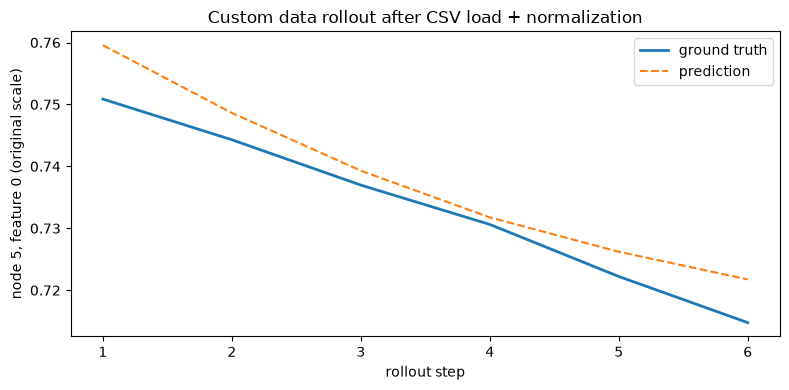

In [11]:
node_id = 5
feature_idx = 0
times = np.arange(1, HOLDOUT_STEPS + 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(times, truth_np[:, node_id, feature_idx], label="ground truth", linewidth=2)
ax.plot(times, pred_np[:, node_id, feature_idx], label="prediction", linestyle="--")
ax.set_xlabel("rollout step")
ax.set_ylabel(f"node {node_id}, feature {feature_idx} (original scale)")
ax.set_title("Custom data rollout after CSV load + normalization")
ax.legend()
fig.tight_layout()
plt.show()


## Checklist for your own dataset

1. **Topology** — Build ``edge_index`` with integer node IDs `0 … N-1`. Undirected
   edges are usually stored as two directed entries `(i, j)` and `(j, i)`.
2. **Alignment** — Every timestep must list all `N` nodes with the same `F` features.
3. **Dynamics** — Features that evolve via neighbor coupling on your graph are a
   natural fit for KoopmanGraph; purely per-node signals with no spatial structure
   are harder to forecast with a topology-aware model.
4. **Missing values** — Impute or mask *before* normalization; the model expects dense tensors.
5. **Units** — Keep a copy of normalization statistics to denormalize predictions.
6. **``time_step``** — Match the physical spacing between snapshots when known.
7. **Rollout loss** — Add a non-zero ``loss_weights.rollout`` when multi-step
   ``predict`` accuracy matters, and set ``rollout_horizon`` to your evaluation horizon.

``fit`` accepts either a :class:`~koopman_graph.data.GraphSnapshotSequence` or a plain
``list[Data]``. ``predict`` accepts ``Data`` or a feature tensor plus ``edge_index``.


## Next steps

- [`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb) — end-to-end workflow on a built-in benchmark.
- [`02_ieee118_bus.ipynb`](02_ieee118_bus.ipynb) — cached MATPOWER topology + synthetic bus dynamics.
- [`03_traffic_network.ipynb`](03_traffic_network.ipynb) — METR-LA traffic speeds from HDF5 cache.
- [`04_grid_attention.ipynb`](04_grid_attention.ipynb) — ``GATEncoder`` on a directional grid.
- [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html) — ``GraphSnapshotSequence``, loss weights, encoders.
